In [2]:
# ── Fetch dataset from GitHub Releases ────────────────────
import os, zipfile, requests
from tqdm import tqdm

GITHUB_URL = "https://github.com/chaayaan/makeup-product-classifier/releases/download/v1.0/dataset.zip"
ZIP_PATH   = "/content/dataset.zip"
DEST_PATH  = "/content/dataset"

if not os.path.exists(DEST_PATH):
    print("📥 Downloading dataset from GitHub...")
    r = requests.get(GITHUB_URL, stream=True)
    total = int(r.headers.get('content-length', 0))
    with open(ZIP_PATH, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as bar:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall("/content")
    os.remove(ZIP_PATH)
    print("✅ Dataset ready at /content/dataset")
else:
    print("✅ Dataset already exists, skipping download.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileExistsError: [Errno 17] File exists: '/content/dataset'

In [3]:
# Install required libraries
!pip install scikit-learn matplotlib seaborn tensorflow pillow -q

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ All libraries imported successfully!
TensorFlow version: 2.19.0


In [4]:
# ── Configuration ──────────────────────────────────────────
DATASET_PATH = '/content/drive/MyDrive/dataset'
IMG_SIZE     = (64, 64)             # resize all images to 64x64
CLASSES      = ['lipstick', 'foundation', 'eyeliner', 'nail polish', 'makeup brush']

# ── Load Images ────────────────────────────────────────────
def load_dataset(dataset_path, img_size, classes):
    images, labels = [], []
    class_counts = {}

    for label in classes:
        folder = os.path.join(dataset_path, label)
        if not os.path.exists(folder):
            print(f"⚠️  Folder not found: {folder}")
            continue

        count = 0
        for filename in os.listdir(folder):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp')):
                img_path = os.path.join(folder, filename)
                try:
                    img = Image.open(img_path).convert('RGB')
                    img = img.resize(img_size)
                    images.append(np.array(img))
                    labels.append(label)
                    count += 1
                except Exception as e:
                    print(f"  Skipped {filename}: {e}")

        class_counts[label] = count
        print(f"  ✅ {label:<20} → {count} images loaded")

    return np.array(images), np.array(labels), class_counts

print("📂 Loading dataset...")
X, y, class_counts = load_dataset(DATASET_PATH, IMG_SIZE, CLASSES)
print(f"\n📊 Total images : {len(X)}")
print(f"📐 Image shape  : {X[0].shape}")

📂 Loading dataset...
  ✅ lipstick             → 150 images loaded
  ✅ foundation           → 40 images loaded
  ✅ eyeliner             → 150 images loaded
  ✅ nail polish          → 150 images loaded
  ✅ makeup brush         → 150 images loaded

📊 Total images : 640
📐 Image shape  : (64, 64, 3)


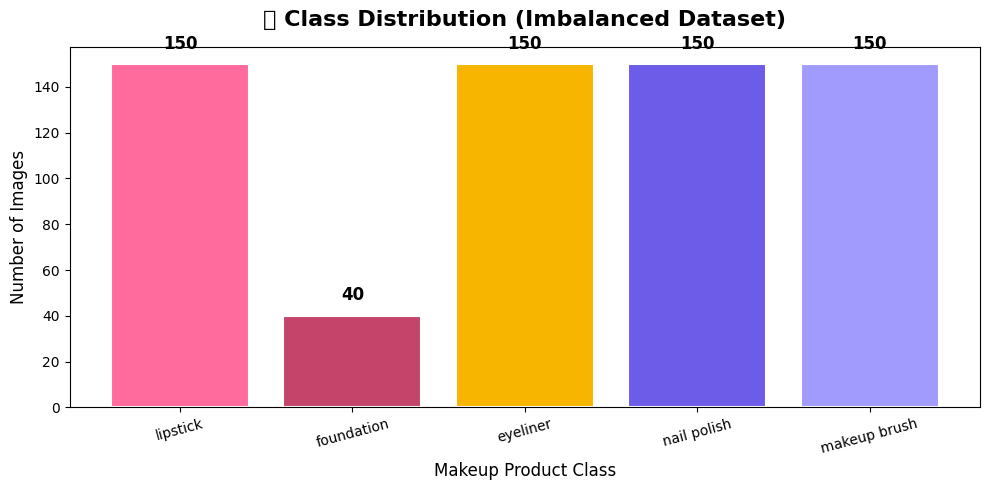

⚠️  Notice: Dataset is intentionally imbalanced across classes


In [5]:
plt.figure(figsize=(10, 5))

colors = ['#FF6B9D', '#C44569', '#F8B500', '#6C5CE7', '#A29BFE']
bars = plt.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('📊 Class Distribution (Imbalanced Dataset)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Makeup Product Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("⚠️  Notice: Dataset is intentionally imbalanced across classes")

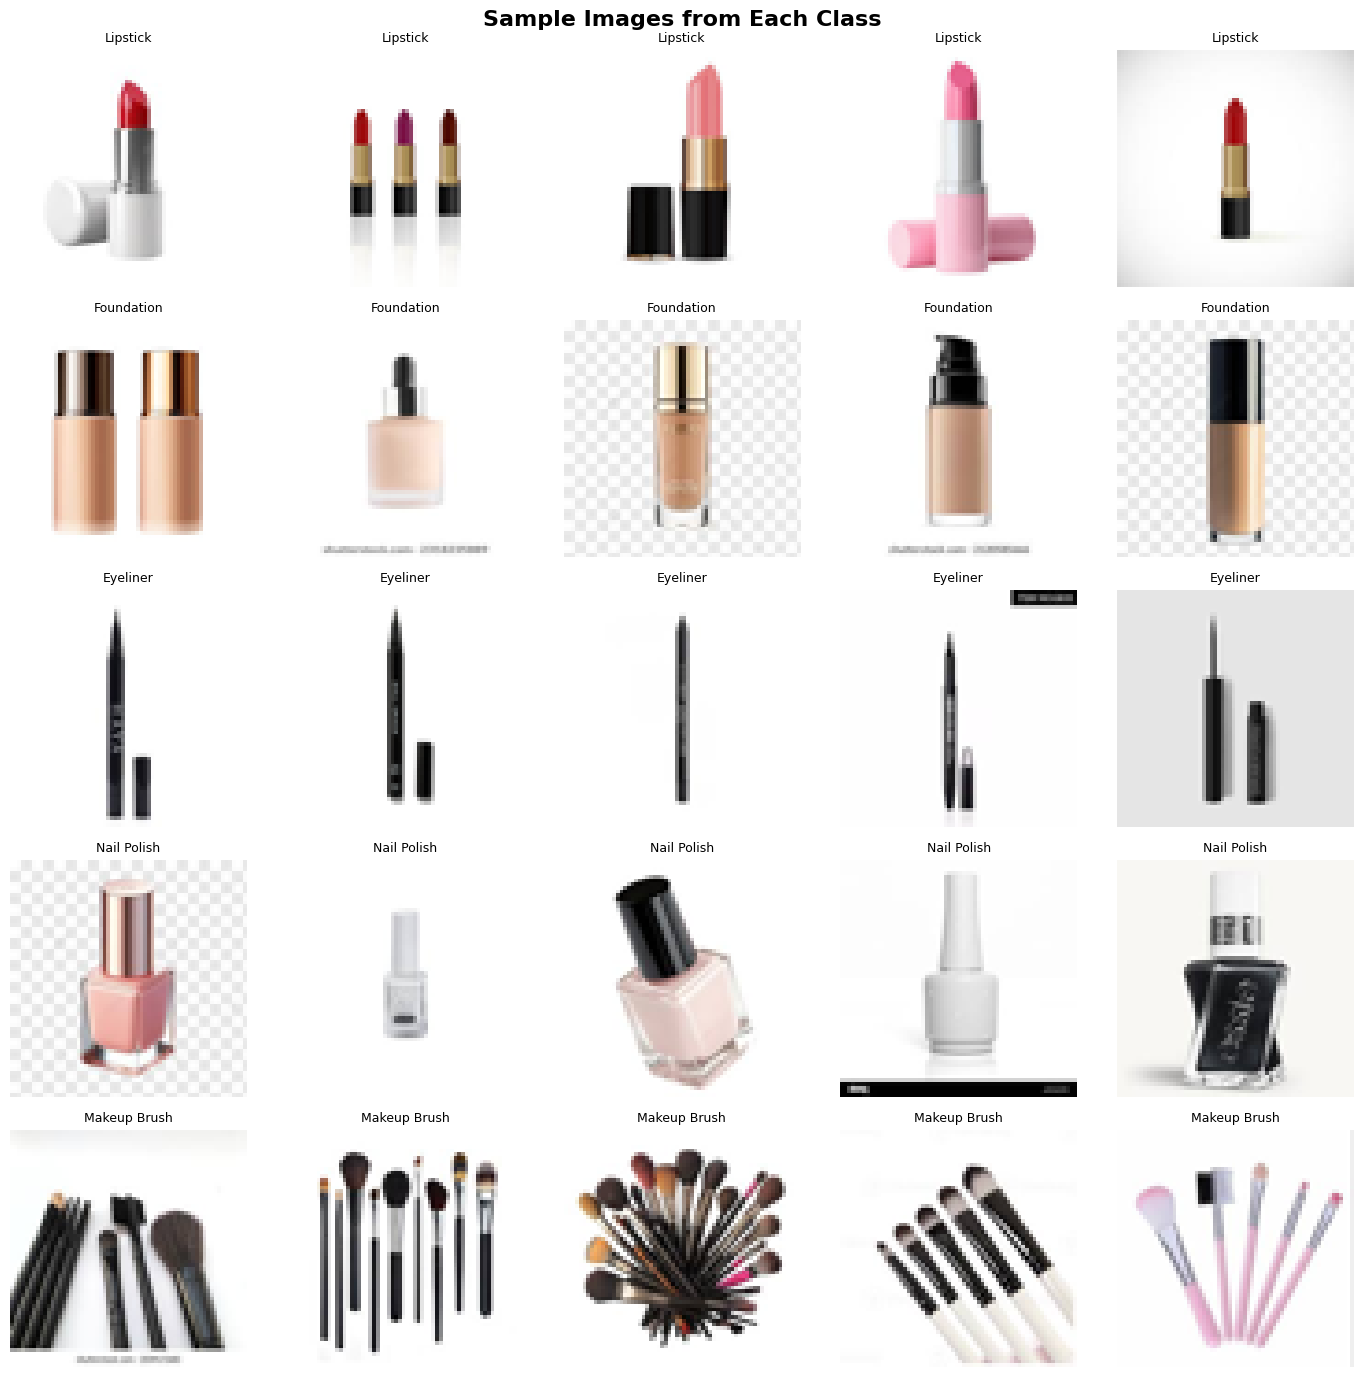

In [6]:
fig, axes = plt.subplots(5, 5, figsize=(14, 14))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold')

for row, cls in enumerate(CLASSES):
    indices = np.where(y == cls)[0][:5]
    for col, idx in enumerate(indices):
        axes[row, col].imshow(X[idx])
        axes[row, col].set_title(cls.replace('_', ' ').title(), fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

🔍 Minority class  : 'foundation'
📷 Current count   : 40 images
🎯 Target count    : 150 images
✨ Images to generate: 110

✅ Generated 110 synthetic Foundation images

📊 Updated class distribution after augmentation:
   eyeliner             : 150 images
   foundation           : 150 images ← augmented
   lipstick             : 150 images
   makeup brush         : 150 images
   nail polish          : 150 images

📦 Total dataset size: 750 images


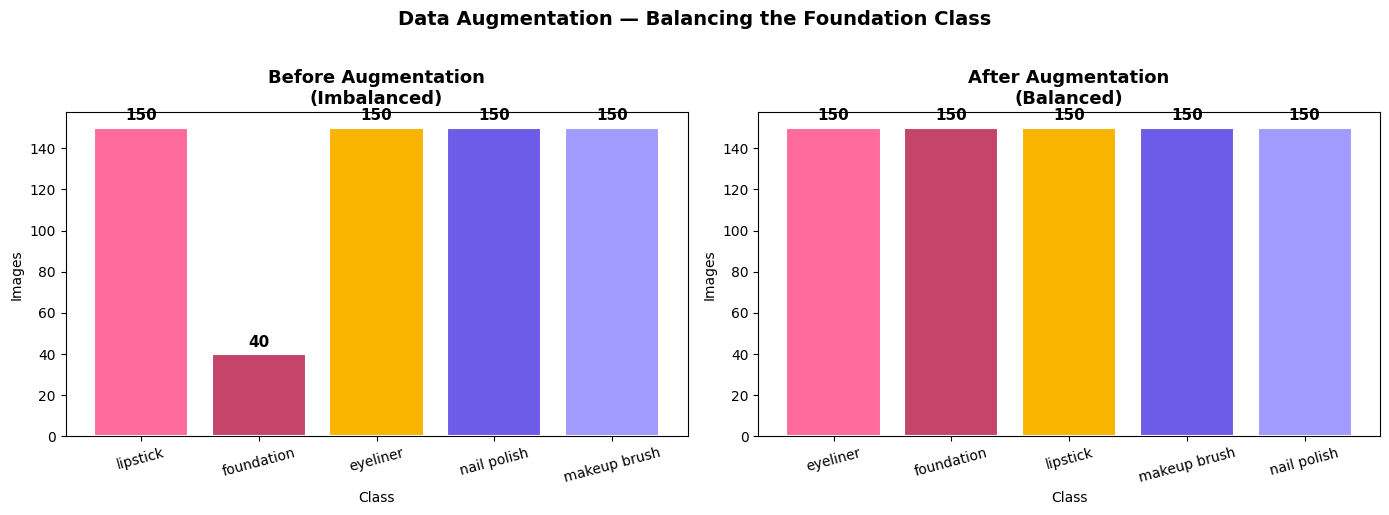

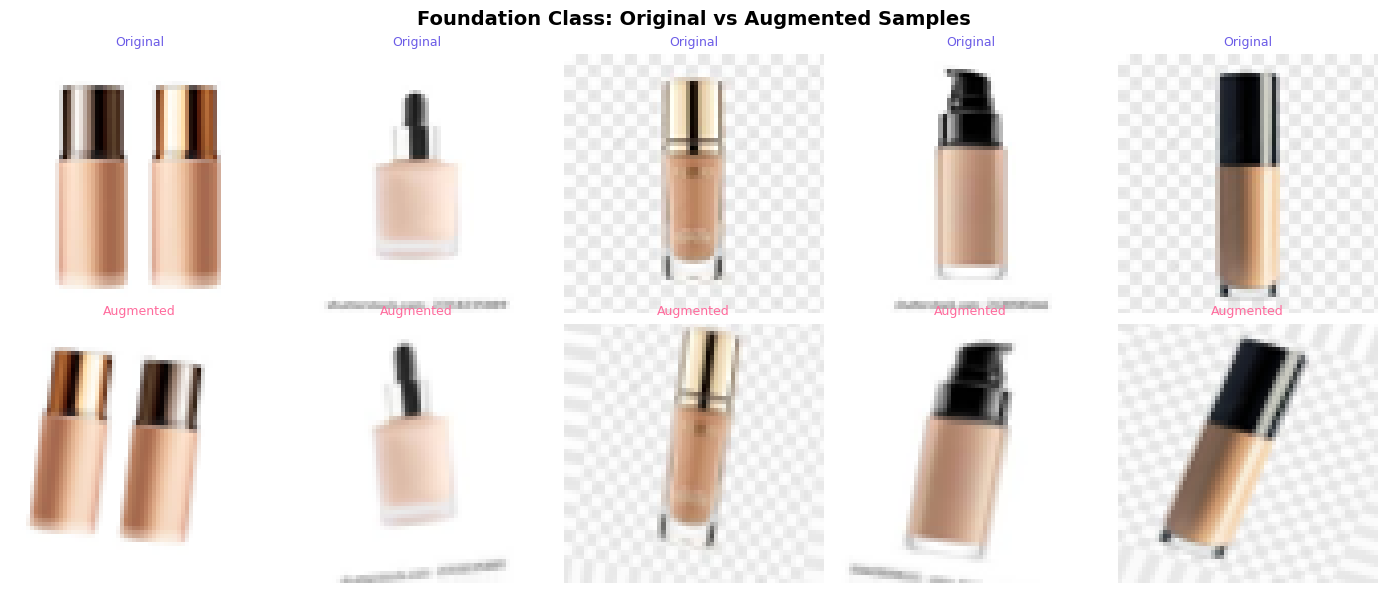


✅ Dataset is now balanced! Proceed to preprocessing and model training.


In [7]:
# ══════════════════════════════════════════════════════════════
# STEP: Data Augmentation — Balance the Minority Class (Foundation)
# ══════════════════════════════════════════════════════════════
# Foundation has only ~40 images vs ~150 for all other classes.
# We apply random transformations to generate synthetic images
# until Foundation reaches ~150 images, creating a balanced dataset.

from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img
import numpy as np

TARGET_COUNT = 150   # target number of images per class
MINORITY_CLASS = 'foundation'

# ── Set up augmentation pipeline ──────────────────────────────
aug_gen = ImageDataGenerator(
    rotation_range=20,        # rotate up to ±20 degrees
    zoom_range=0.15,          # zoom in/out up to 15%
    width_shift_range=0.1,    # shift horizontally up to 10%
    height_shift_range=0.1,   # shift vertically up to 10%
    horizontal_flip=True,     # randomly flip left-right
    fill_mode='nearest'       # fill empty pixels with nearest value
)

# ── Get existing Foundation images ────────────────────────────
minority_mask  = (y == MINORITY_CLASS)
X_minority     = X[minority_mask]          # shape: (40, 64, 64, 3)
current_count  = len(X_minority)
needed         = TARGET_COUNT - current_count

print(f"🔍 Minority class  : '{MINORITY_CLASS}'")
print(f"📷 Current count   : {current_count} images")
print(f"🎯 Target count    : {TARGET_COUNT} images")
print(f"✨ Images to generate: {needed}")
print()

# ── Generate synthetic images ─────────────────────────────────
synthetic_images = []
synthetic_labels = []

# Cycle through existing minority images, augmenting each
# until we reach the desired count
i = 0
while len(synthetic_images) < needed:
    # Pick one source image (cycle through all)
    src_img = X_minority[i % current_count].astype('float32')
    src_img_expanded = np.expand_dims(src_img, axis=0)   # (1, 64, 64, 3)

    # Generate one augmented version
    aug_iter = aug_gen.flow(src_img_expanded, batch_size=1)
    aug_img  = next(aug_iter)[0].astype('uint8')          # back to uint8

    synthetic_images.append(aug_img)
    synthetic_labels.append(MINORITY_CLASS)
    i += 1

synthetic_images = np.array(synthetic_images)   # (needed, 64, 64, 3)
synthetic_labels = np.array(synthetic_labels)

print(f"✅ Generated {len(synthetic_images)} synthetic Foundation images")

# ── Merge augmented data back into the full dataset ────────────
X = np.concatenate([X, synthetic_images], axis=0)
y = np.concatenate([y, synthetic_labels], axis=0)

# ── Verify new class distribution ─────────────────────────────
unique, counts = np.unique(y, return_counts=True)
new_class_counts = dict(zip(unique, counts))

print(f"\n📊 Updated class distribution after augmentation:")
for cls, cnt in new_class_counts.items():
    tag = " ← augmented" if cls == MINORITY_CLASS else ""
    print(f"   {cls:<20} : {cnt} images{tag}")
print(f"\n📦 Total dataset size: {len(X)} images")

# ── Visualise before vs. after ────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
before_counts = {k: v for k, v in class_counts.items()}
colors = ['#FF6B9D', '#C44569', '#F8B500', '#6C5CE7', '#A29BFE']
bars0 = axes[0].bar(before_counts.keys(), before_counts.values(),
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars0, before_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(cnt), ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Before Augmentation\n(Imbalanced)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Images')
axes[0].tick_params(axis='x', rotation=15)

# After
bars1 = axes[1].bar(new_class_counts.keys(), new_class_counts.values(),
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars1, new_class_counts.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(cnt), ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_title('After Augmentation\n(Balanced)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Images')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Data Augmentation — Balancing the Foundation Class',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Show sample augmented images ──────────────────────────────
fig2, axes2 = plt.subplots(2, 5, figsize=(14, 6))
fig2.suptitle('Foundation Class: Original vs Augmented Samples',
              fontsize=14, fontweight='bold')

for col in range(5):
    axes2[0, col].imshow(X_minority[col])
    axes2[0, col].set_title('Original', fontsize=9, color='#6C5CE7')
    axes2[0, col].axis('off')

    axes2[1, col].imshow(synthetic_images[col])
    axes2[1, col].set_title('Augmented', fontsize=9, color='#FF6B9D')
    axes2[1, col].axis('off')

plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Dataset is now balanced! Proceed to preprocessing and model training.")

In [8]:
# ── Normalize pixel values to [0, 1] ──────────────────────
X_normalized = X.astype('float32') / 255.0

# ── Encode labels ─────────────────────────────────────────
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# ── Train / Test Split (80 / 20) ──────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n📦 Training samples : {len(X_train)}")
print(f"🧪 Testing samples  : {len(X_test)}")

# ── Flatten for classical ML models ───────────────────────
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test),  -1)
print(f"\n🔷 Flattened shape  : {X_train_flat.shape}")

# ── PCA to reduce dimensions (speeds up classical ML) ─────
pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca  = pca.transform(X_test_flat)
print(f"🔷 After PCA shape  : {X_train_pca.shape}")
print(f"📉 Variance kept    : {pca.explained_variance_ratio_.sum():.2%}")

Label mapping: {np.str_('eyeliner'): np.int64(0), np.str_('foundation'): np.int64(1), np.str_('lipstick'): np.int64(2), np.str_('makeup brush'): np.int64(3), np.str_('nail polish'): np.int64(4)}

📦 Training samples : 600
🧪 Testing samples  : 150

🔷 Flattened shape  : (600, 12288)
🔷 After PCA shape  : (600, 100)
📉 Variance kept    : 91.26%


In [9]:
results = {}   # store all model results here

def evaluate_model(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

    print(f"\n{'='*50}")
    print(f"  Model : {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=le.classes_)}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f'cm_{name.replace(" ","_")}.png', dpi=150)
    plt.show()

    return acc

🌲 Training Random Forest...

  Model : Random Forest
  Accuracy  : 0.6733
  Precision : 0.6772
  Recall    : 0.6733
  F1-Score  : 0.6689

              precision    recall  f1-score   support

    eyeliner       0.73      0.63      0.68        30
  foundation       0.62      0.70      0.66        30
    lipstick       0.60      0.60      0.60        30
makeup brush       0.73      0.53      0.62        30
 nail polish       0.71      0.90      0.79        30

    accuracy                           0.67       150
   macro avg       0.68      0.67      0.67       150
weighted avg       0.68      0.67      0.67       150



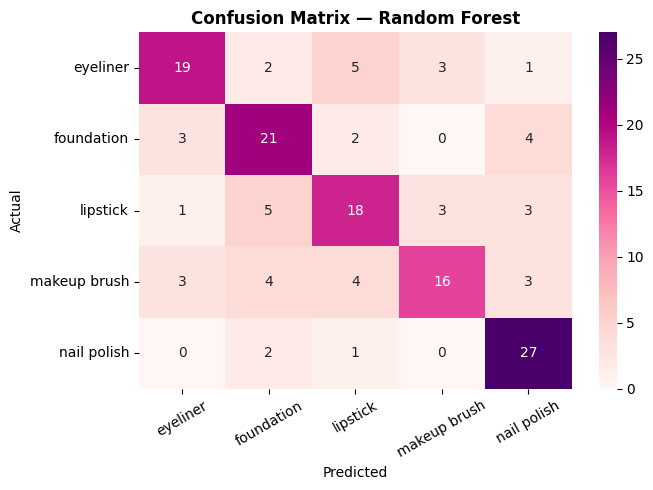

0.6733333333333333

In [10]:
print("🌲 Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_pca, y_train)
y_pred_rf = rf.predict(X_test_pca)
evaluate_model("Random Forest", y_test, y_pred_rf)

⚙️  Training SVM (this may take a minute)...

  Model : SVM
  Accuracy  : 0.7467
  Precision : 0.7655
  Recall    : 0.7467
  F1-Score  : 0.7486

              precision    recall  f1-score   support

    eyeliner       0.91      0.70      0.79        30
  foundation       0.84      0.70      0.76        30
    lipstick       0.59      0.73      0.66        30
makeup brush       0.75      0.70      0.72        30
 nail polish       0.73      0.90      0.81        30

    accuracy                           0.75       150
   macro avg       0.77      0.75      0.75       150
weighted avg       0.77      0.75      0.75       150



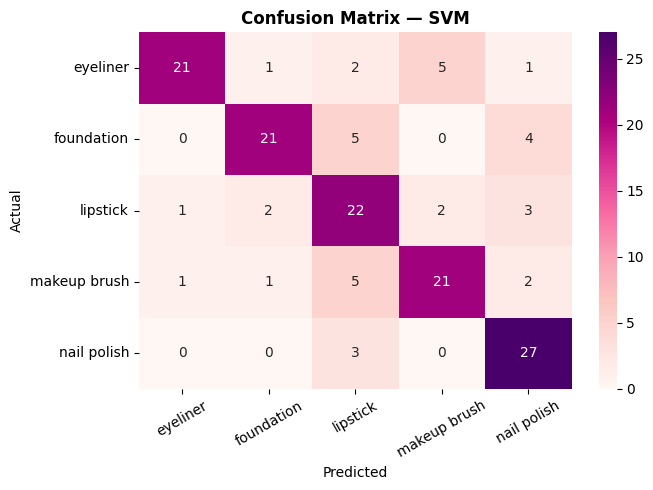

0.7466666666666667

In [11]:
print("⚙️  Training SVM (this may take a minute)...")
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_pca, y_train)
y_pred_svm = svm.predict(X_test_pca)
evaluate_model("SVM", y_test, y_pred_svm)

📍 Training KNN...

  Model : KNN
  Accuracy  : 0.6067
  Precision : 0.6192
  Recall    : 0.6067
  F1-Score  : 0.5873

              precision    recall  f1-score   support

    eyeliner       0.74      0.67      0.70        30
  foundation       0.58      0.70      0.64        30
    lipstick       0.70      0.47      0.56        30
makeup brush       0.53      0.27      0.36        30
 nail polish       0.54      0.93      0.68        30

    accuracy                           0.61       150
   macro avg       0.62      0.61      0.59       150
weighted avg       0.62      0.61      0.59       150



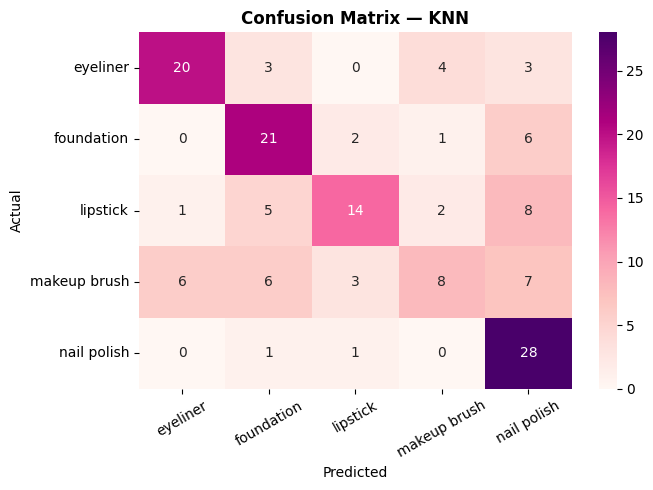

0.6066666666666667

In [12]:
print("📍 Training KNN...")
knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=-1)
knn.fit(X_train_pca, y_train)
y_pred_knn = knn.predict(X_test_pca)
evaluate_model("KNN", y_test, y_pred_knn)

📈 Training Logistic Regression...

  Model : Logistic Regression
  Accuracy  : 0.6333
  Precision : 0.6378
  Recall    : 0.6333
  F1-Score  : 0.6302

              precision    recall  f1-score   support

    eyeliner       0.71      0.57      0.63        30
  foundation       0.59      0.63      0.61        30
    lipstick       0.67      0.53      0.59        30
makeup brush       0.56      0.60      0.58        30
 nail polish       0.66      0.83      0.74        30

    accuracy                           0.63       150
   macro avg       0.64      0.63      0.63       150
weighted avg       0.64      0.63      0.63       150



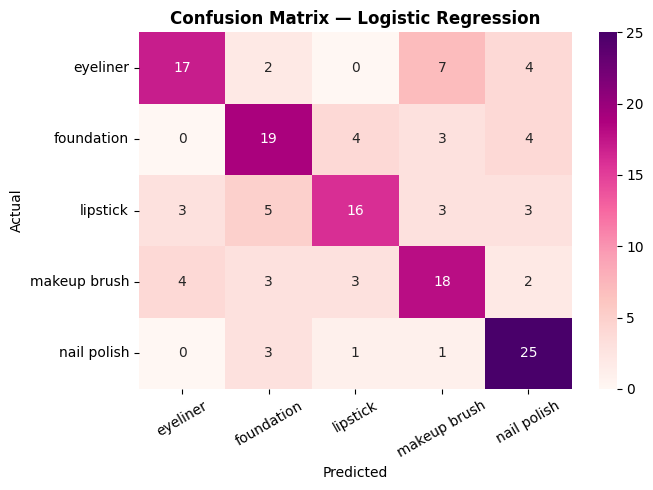

0.6333333333333333

In [13]:
from sklearn.linear_model import LogisticRegression

print("📈 Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_pca, y_train)
y_pred_lr = lr.predict(X_test_pca)
evaluate_model("Logistic Regression", y_test, y_pred_lr)


📊 COMPARATIVE RESULTS

                     Accuracy  Precision  Recall  F1-Score
Random Forest          0.6733     0.6772  0.6733    0.6689
SVM                    0.7467     0.7655  0.7467    0.7486
KNN                    0.6067     0.6192  0.6067    0.5873
Logistic Regression    0.6333     0.6378  0.6333    0.6302


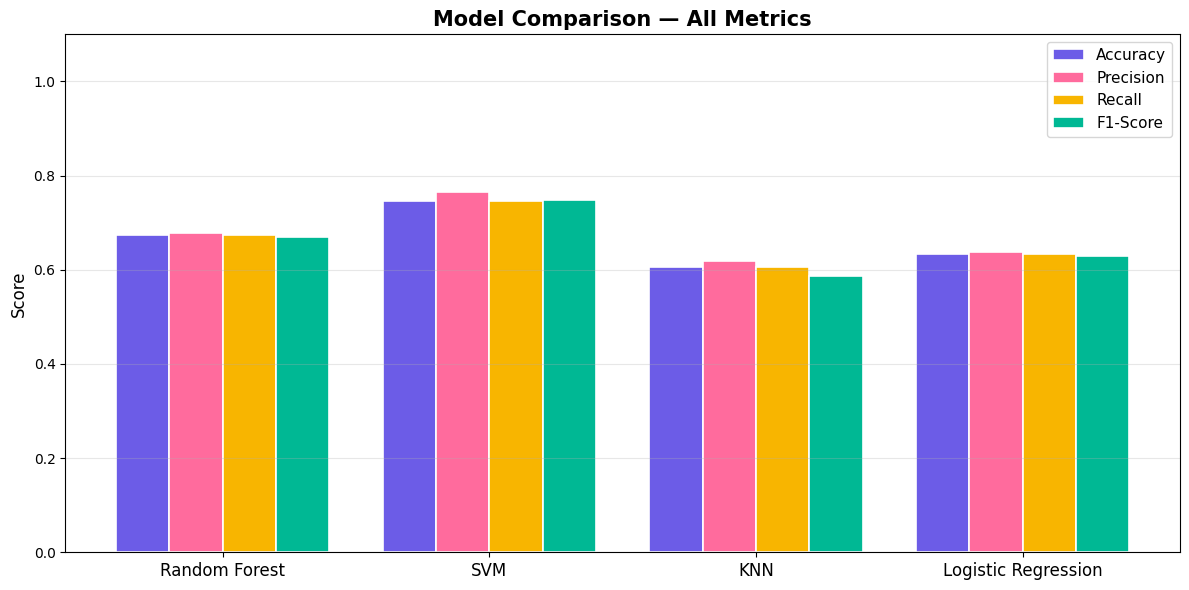


🏆 Best Model by Accuracy: SVM (74.67%)


In [14]:
import pandas as pd

df_results = pd.DataFrame(results).T.round(4)
print("\n📊 COMPARATIVE RESULTS\n")
print(df_results.to_string())

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_results))
w = 0.2
colors_bar = ['#6C5CE7', '#FF6B9D', '#F8B500', '#00B894']

for i, (col, color) in enumerate(zip(df_results.columns, colors_bar)):
    ax.bar(x + i*w, df_results[col], width=w, label=col,
           color=color, edgecolor='white', linewidth=1.2)

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(df_results.index, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best = df_results['Accuracy'].idxmax()
print(f"\n🏆 Best Model by Accuracy: {best} ({df_results.loc[best,'Accuracy']:.2%})")

❌ Unknown model. Choose from: svm, rf, knn, lr


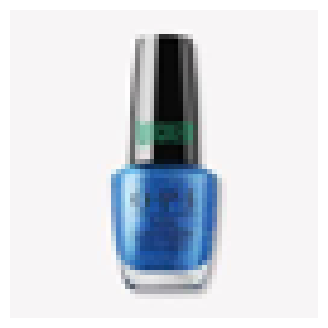

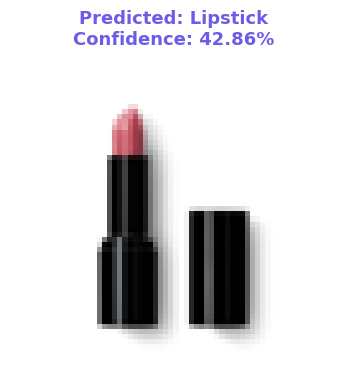

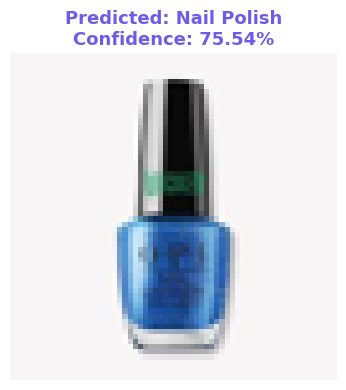

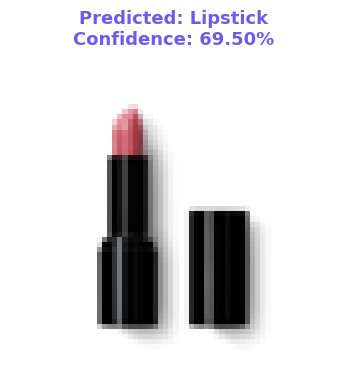

np.str_('lipstick')

In [19]:
from skimage.feature import hog
from PIL import Image

def predict_image(img_path, model_choice='svm'):
    img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
    img_array = np.array(img).astype('float32') / 255.0

    plt.figure(figsize=(4, 4))
    plt.imshow(img_array)
    plt.axis('off')

    # ✅ Raw pixels — matches training
    feat = img_array.flatten().reshape(1, -1)   # → 12288 features
    feat_pca = pca.transform(feat)

    model_map = {'svm': svm, 'rf': rf, 'knn': knn, 'lr': lr}

    if model_choice not in model_map:
        print(f"❌ Unknown model. Choose from: svm, rf, knn, lr")
        return None

    class_idx = model_map[model_choice].predict(feat_pca)[0]
    predicted_class = le.classes_[class_idx]

    if hasattr(model_map[model_choice], 'predict_proba'):
        proba = model_map[model_choice].predict_proba(feat_pca)[0]
        confidence = proba[class_idx]
        title = f"Predicted: {predicted_class.replace('_',' ').title()}\nConfidence: {confidence:.2%}"
    else:
        title = f"Predicted: {predicted_class.replace('_',' ').title()}"

    plt.title(title, fontsize=13, fontweight='bold', color='#6C5CE7')
    plt.tight_layout()
    plt.show()
    return predicted_class

# ── Usage ──────────────────────────────────────────────────
predict_image('/content/nl2.jfif', model_choice='scm')
predict_image('/content/lp.jpg', model_choice='knn')
predict_image('/content/nl2.jfif', model_choice='lr')
predict_image('/content/lp.jpg', model_choice='rf')